# PE7023 - Project
## Part1.3


Diego de Miranda Gomes

Emuobosa Patience Ojoboh

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
## Reservoir properties
reservoir_pressure = 3800 # Pressure in psi
reservoir_temperature = 200 # Temperature in °F
k = 40 # Permeability in mD
h = 150 # Thickness in ft
re = 372 # Drainage radius in ft
S = 0 # Skin factor
API = 45 # API gravity
muo = 0.902 # Viscosity in cp
gas_specific_gravity = 0.6636 # Gas specific gravity
GOR = 800 # Gas-oil ratio in scf/STB
Pb = 3800 # Bubble point pressure in psi
Bo = 1.2 # Formation volume factor in bbl/STB
max_field_rate = 45000
number_of_wells = 7
max_rate_per_well = max_field_rate / number_of_wells

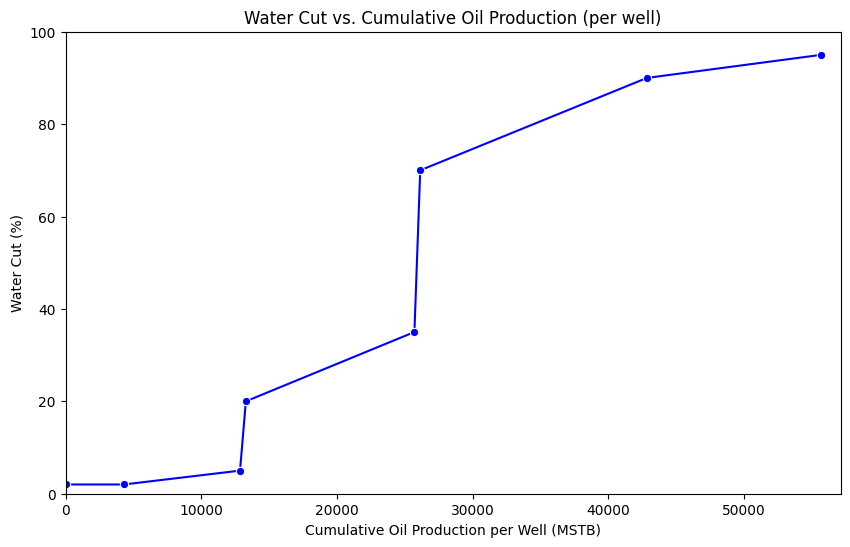

In [5]:
df_wcut_vs_np = pd.read_csv('datasets/wcut_x_np.csv')
df_wcut_vs_np.columns = ['NP [MSTB,oil]', 'WC [%]']
##Divide NP by number of wells to get NP per well
df_wcut_vs_np['NP per well [MSTB,oil]'] = df_wcut_vs_np['NP [MSTB,oil]'] / number_of_wells
# Plotting Water Cut vs. Cumulative Oil Production  
plt.figure(figsize=(10, 6))
sns.lineplot(x=df_wcut_vs_np['NP per well [MSTB,oil]'], y=df_wcut_vs_np['WC [%]'], marker='o', color='blue')
plt.title('Water Cut vs. Cumulative Oil Production (per well)')
plt.xlabel('Cumulative Oil Production per Well (MSTB)')
plt.ylabel('Water Cut (%)')
plt.xlim(0, 400000 / number_of_wells)  # Set x-axis limit to max NP per well
plt.ylim(0, 100)
# plt.grid()
plt.show()


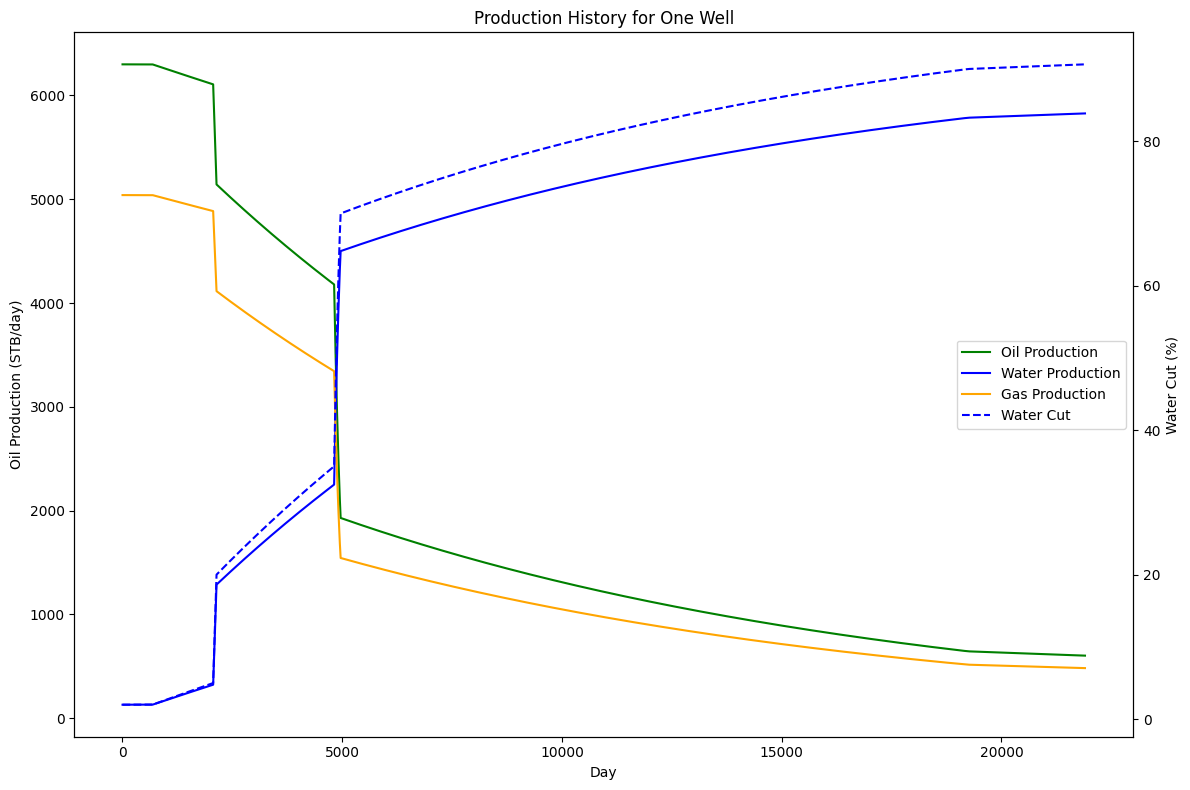

In [6]:
## Calculate production history for 1 well
total_days = 365 * 60 # Simulate for 5 years
daily_oil_production = []
daily_water_production = []
daily_gas_production = []
daily_water_cut = []
cumulative_production = 0
for day in range(total_days):
    current_wcut = np.interp(cumulative_production, df_wcut_vs_np['NP per well [MSTB,oil]'], df_wcut_vs_np['WC [%]'])
    current_oil_rate = max_rate_per_well * (1 - current_wcut / 100)
    daily_oil_production.append(current_oil_rate)
    daily_water_cut.append(current_wcut)
    daily_water_production.append(max_rate_per_well * (current_wcut / 100))
    daily_gas_production.append(current_oil_rate * GOR / 1000)  # Convert to Mscf
    cumulative_production += current_oil_rate/1000  # Convert to MSTB

# Create a dataframe for plotting
production_df = pd.DataFrame({
    'Day': range(1, total_days + 1),
    'Oil Production (STB/day)': daily_oil_production,
    'Water Production (STB/day)': daily_water_production,
    'Gas Production (Mscf/day)': daily_gas_production,
    'Water Cut (%)': daily_water_cut
})
# Plotting production history
plt.figure(figsize=(12, 8))

# Primary axis
ax = plt.gca()

l1 = sns.lineplot(x=production_df['Day'], y=production_df['Oil Production (STB/day)'],
                  label='Oil Production', color='green', ax=ax)

l2 = sns.lineplot(x=production_df['Day'], y=production_df['Water Production (STB/day)'],
                  label='Water Production', color='blue', ax=ax)

l3 = sns.lineplot(x=production_df['Day'], y=production_df['Gas Production (Mscf/day)'],
                  label='Gas Production', color='orange', ax=ax)

# Secondary axis
ax2 = ax.twinx()

l4 = sns.lineplot(x=production_df['Day'], y=production_df['Water Cut (%)'],
                   color='blue', label = 'Water Cut', linestyle='--', ax=ax2)

ax2.set_ylabel('Water Cut (%)')

# 🔥 Combine legends
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax.legend(lines_1 + lines_2, labels_1 + labels_2)
## Hide legend for ax2
ax2.get_legend().remove()
plt.title('Production History for One Well')
plt.xlabel('Day')

plt.tight_layout()
plt.show()



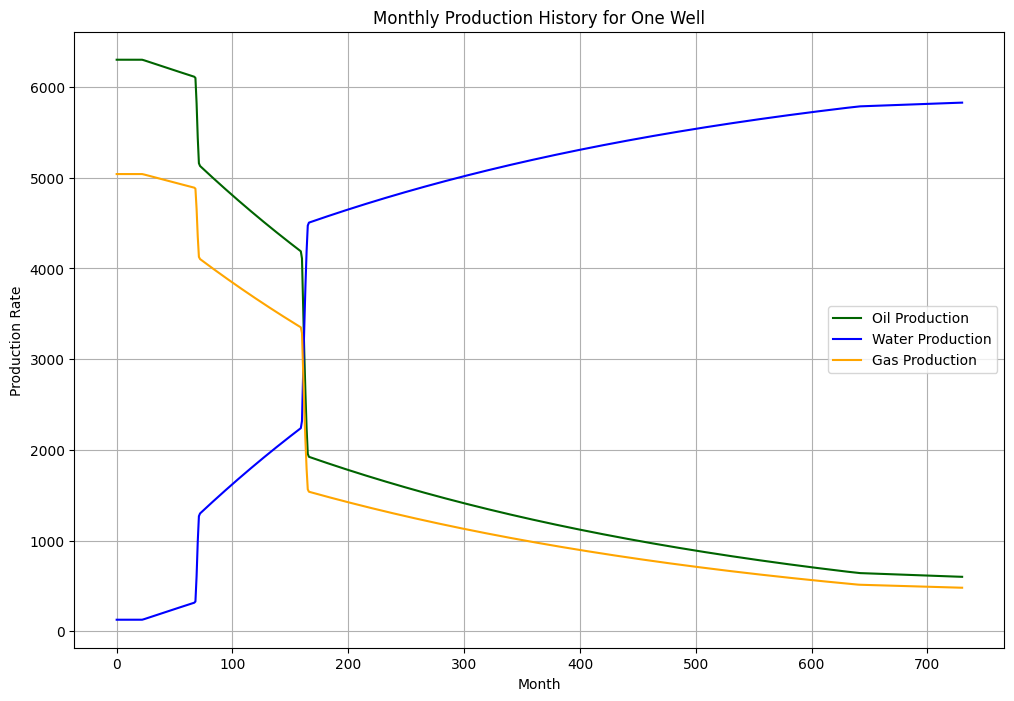

In [7]:
## Convert production_df for a montly basis
production_df['Month'] = production_df['Day'] // 30
monthly_production_df = production_df.groupby('Month').mean().reset_index()
# Plotting monthly production history
plt.figure(figsize=(12, 8))
sns.lineplot(x=monthly_production_df['Month'], y=monthly_production_df['Oil Production (STB/day)'], label='Oil Production', color='darkgreen')
sns.lineplot(x=monthly_production_df['Month'], y=monthly_production_df['Water Production (STB/day)'], label='Water Production', color='blue')
sns.lineplot(x=monthly_production_df['Month'], y=monthly_production_df['Gas Production (Mscf/day)'], label='Gas Production', color='orange')

plt.title('Monthly Production History for One Well')
plt.xlabel('Month')
plt.ylabel('Production Rate')
plt.legend()
plt.grid()

In [8]:
## Open minimuim gas lift injection rate table
min_gli_rate_table = pd.read_csv('datasets/min_gli_rate_table.csv')
## order the table by water cut
min_gli_rate_table = min_gli_rate_table.sort_values(by='Water Cut (%)')
print(min_gli_rate_table)

   Water Cut (%)  Minimum Gas Lift Injection Rate (mmscf/day)
0              2                                          0.0
3              5                                          0.0
1             20                                          0.2
2             35                                          0.6
4             70                                          1.2
5             90                                          1.6
6             95                                          1.6


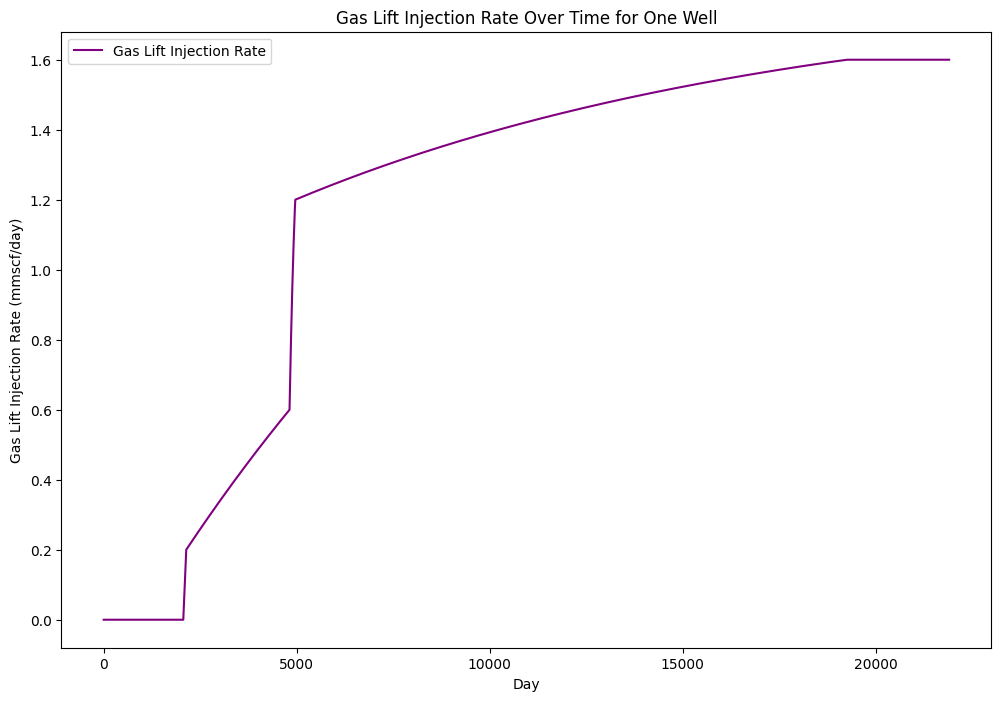

In [9]:
## Calculate gas lift injection rate for well 1 using production history and water cut
production_df['Gas Lift Injection Rate (mmscf/day)'] = production_df.apply(lambda row: np.interp(row['Water Cut (%)'], min_gli_rate_table['Water Cut (%)'], min_gli_rate_table['Minimum Gas Lift Injection Rate (mmscf/day)']), axis=1)
# Plotting Gas Lift Injection Rate over time
plt.figure(figsize=(12, 8))
sns.lineplot(x=production_df['Day'], y=production_df['Gas Lift Injection Rate (mmscf/day)'], label='Gas Lift Injection Rate', color='purple')
plt.title('Gas Lift Injection Rate Over Time for One Well')
plt.xlabel('Day')
plt.ylabel('Gas Lift Injection Rate (mmscf/day)')
plt.legend()
# plt.grid()


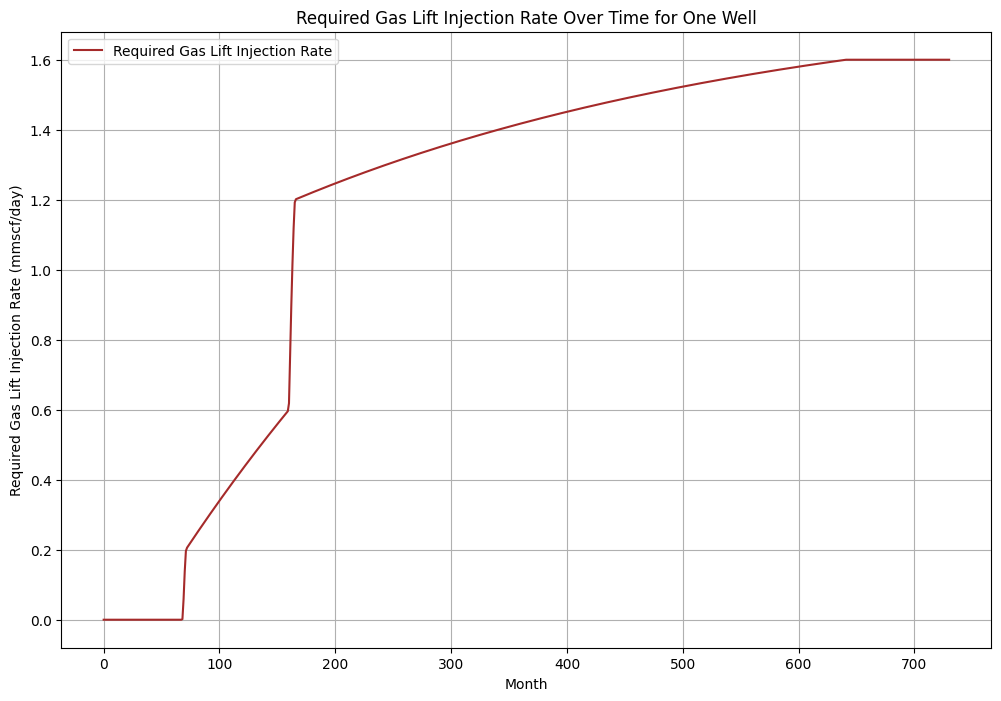

In [10]:
## Calculate gas lift injection rate required to maintain the maximum rate per well for each month
monthly_production_df['Required GLI Rate (mmscf/day)'] = monthly_production_df.apply(lambda row: np.interp(row['Water Cut (%)'], min_gli_rate_table['Water Cut (%)'], min_gli_rate_table['Minimum Gas Lift Injection Rate (mmscf/day)']), axis=1)
# Plotting Required Gas Lift Injection Rate over time
plt.figure(figsize=(12, 8))
sns.lineplot(x=monthly_production_df['Month'], y=monthly_production_df['Required GLI Rate (mmscf/day)'], label='Required Gas Lift Injection Rate', color='brown')
plt.title('Required Gas Lift Injection Rate Over Time for One Well')
plt.xlabel('Month')
plt.ylabel('Required Gas Lift Injection Rate (mmscf/day)')
plt.legend()
plt.grid()

In [11]:
## Show gas lift rate for 5%, 40% and 80% water cut
wcut_levels = [5, 40, 80]
gli_rates = np.interp(wcut_levels, min_gli_rate_table['Water Cut (%)'], min_gli_rate_table['Minimum Gas Lift Injection Rate (mmscf/day)'])
for wcut, gli_rate in zip(wcut_levels, gli_rates):
    print(f'Gas Lift Injection Rate for {wcut}% Water Cut: {gli_rate:.2f} mmscf/day')
    

Gas Lift Injection Rate for 5% Water Cut: 0.00 mmscf/day
Gas Lift Injection Rate for 40% Water Cut: 0.69 mmscf/day
Gas Lift Injection Rate for 80% Water Cut: 1.40 mmscf/day


In [12]:
# Load all wells production data from Excel file
# Path to your Excel file
file_path = "datasets/part1.3_well_results.xlsx"

# Load all sheets into a dictionary
sheets_dict = pd.read_excel(file_path, sheet_name=None)

# Combine into a single DataFrame
df_wells_results = pd.concat(
    [df.assign(Sheet=name) for name, df in sheets_dict.items()],
    ignore_index=True
)
# Separate collumn 'sheet' by '-'
df_wells_results[['Number of Wells', 'WC']] = df_wells_results['Sheet'].str.split('-', expand=True)
df_wells_results.head()

,Name,Type,Branch,Pressure (out),Temperature (out),ST Liquid Rate,ST Oil Rate,ST Water Rate,ST Gas Rate,ST GOR,ST Wcut,Fl Gas Rate,Fl Wcut,Sheet,Number of Wells,WC
0,Cpl,Completion,W1,2510.563,200.4512,6460.354,6137.337,323.0177,4.909869,800.0,5.0,0.013072,4.043688,7-5%,7,5%
1,Cpl,Completion,W3,2507.191,200.4527,6474.239,6150.527,323.7120,4.920422,800.0,5.0,0.013148,4.044794,7-5%,7,5%
2,Cpl,Completion,W7,2534.575,200.4407,6361.018,6042.968,318.0509,4.834374,800.0,5.0,0.012541,4.035801,7-5%,7,5%
3,Cpl,Completion,W5,2536.689,200.4398,6352.231,6034.620,317.6116,4.827696,800.0,5.0,0.012495,4.035106,7-5%,7,5%
4,Cpl,Completion,W4,2492.214,200.4591,6535.727,6208.941,326.7864,4.967153,800.0,5.0,0.013488,4.049705,7-5%,7,5%


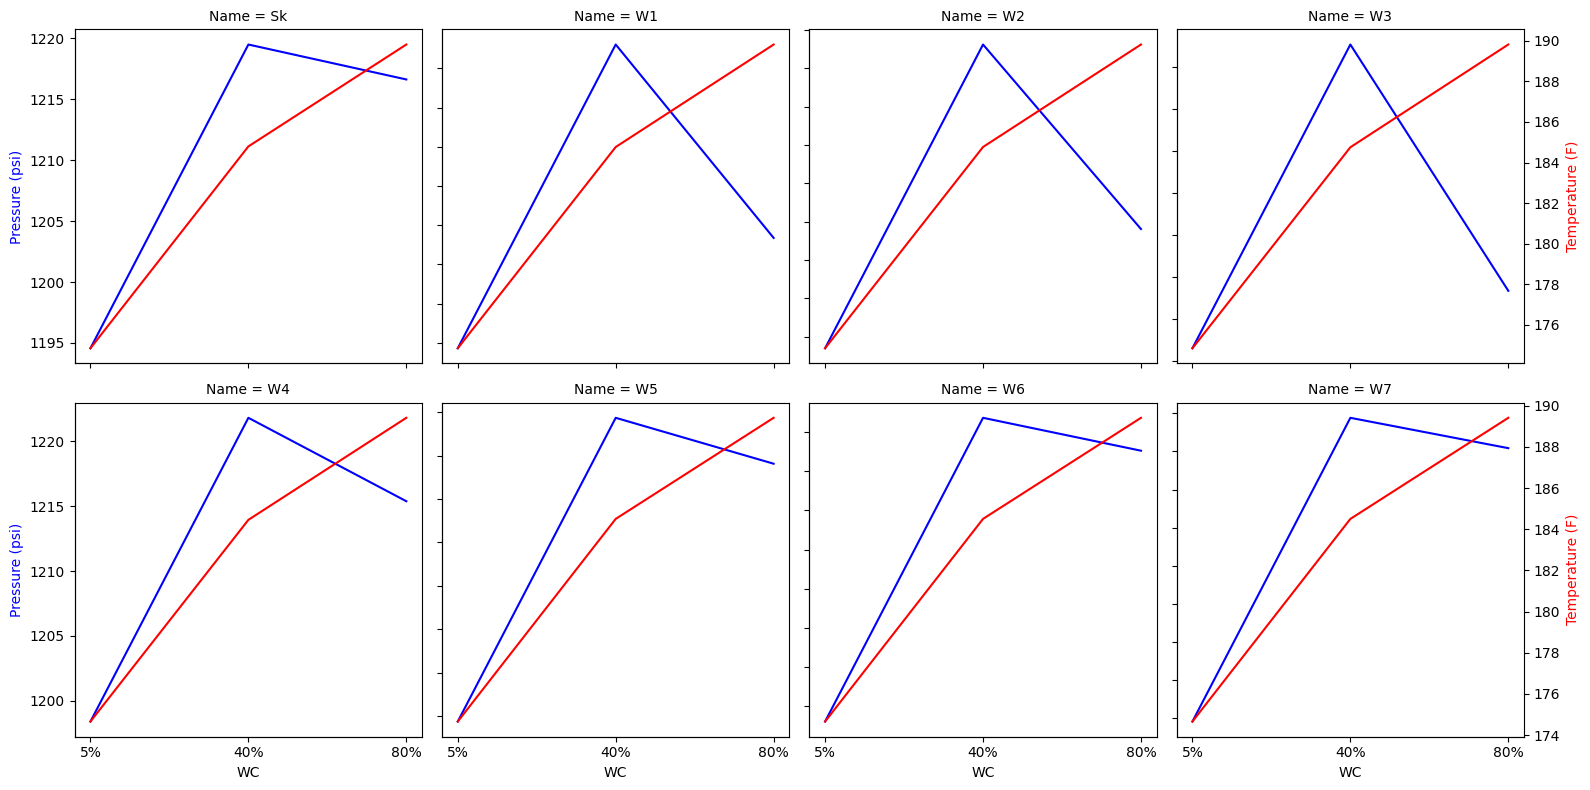

In [13]:
filtered_df = df_wells_results[df_wells_results['Number of Wells'] == '7']
names_to_filter = ['W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'Sk']
filtered_df = filtered_df[filtered_df['Name'].isin(names_to_filter)]

g = sns.FacetGrid(filtered_df, col="Name", col_wrap=4, height=4, sharey=False)

n_cols = 4  # same as col_wrap

for i, (ax, name) in enumerate(zip(g.axes.flat, filtered_df["Name"].unique())):
    
    data = filtered_df[filtered_df["Name"] == name]
    
    # --- Primary axis (Pressure)
    sns.lineplot(data=data, x="WC", y="Pressure (out)", color='blue', ax=ax)
    
    # Remove labels/ticks by default
    ax.set_ylabel("")
    ax.tick_params(axis='y', left=False, labelleft=False)
    
    # Leftmost plots → show pressure axis
    if i % n_cols == 0:
        ax.set_ylabel("Pressure (psi)", color='blue')
        ax.tick_params(axis='y', left=True, labelleft=True)
    
    # --- Secondary axis (Temperature)
    ax2 = ax.twinx()
    sns.lineplot(data=data, x="WC", y="Temperature (out)", ax=ax2, color='red')
    
    ax2.set_ylabel("")
    ax2.tick_params(axis='y', right=False, labelright=False)
    
    # Rightmost plots → show temperature axis
    if i % n_cols == (n_cols - 1):
        ax2.set_ylabel("Temperature (F)", color='red')
        ax2.tick_params(axis='y', right=True, labelright=True)

plt.tight_layout()
plt.show()


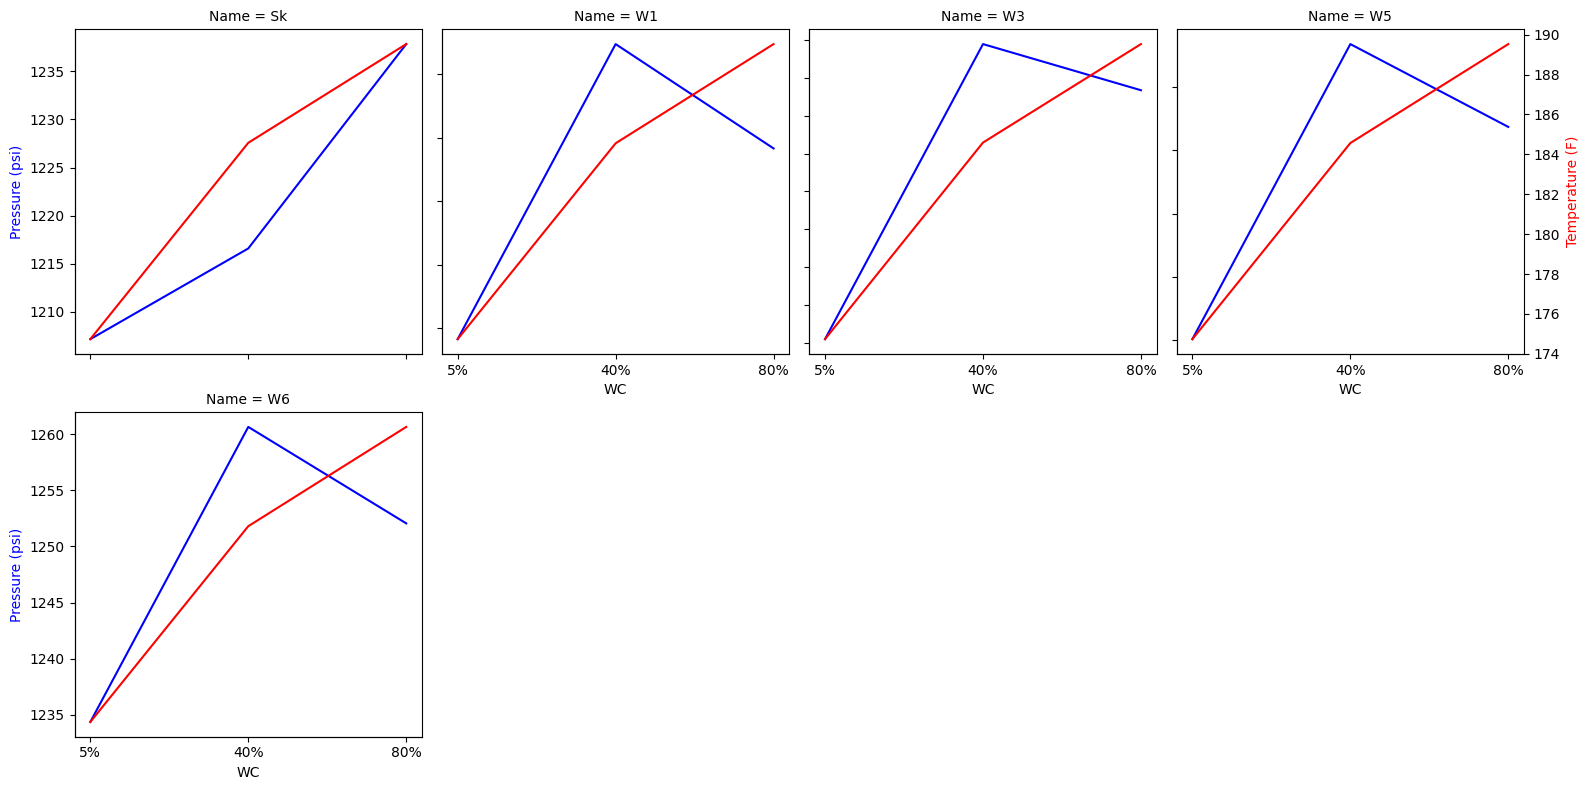

In [14]:
filtered_df = df_wells_results[df_wells_results['Number of Wells'] == '4']
names_to_filter = ['W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'Sk']
filtered_df = filtered_df[filtered_df['Name'].isin(names_to_filter)]
# Force Order by WC [40%, 5%, 80%]
filtered_df['WC'] = pd.Categorical(filtered_df['WC'], categories=['5%', '40%', '80%'], ordered=True)


g = sns.FacetGrid(filtered_df, col="Name", col_wrap=4, height=4, sharey=False)

n_cols = 4  # same as col_wrap

for i, (ax, name) in enumerate(zip(g.axes.flat, filtered_df["Name"].unique())):
    
    data = filtered_df[filtered_df["Name"] == name]
    
    # --- Primary axis (Pressure)
    sns.lineplot(data=data, x="WC", y="Pressure (out)", color='blue', ax=ax)
    
    # Remove labels/ticks by default
    ax.set_ylabel("")
    ax.tick_params(axis='y', left=False, labelleft=False)
    
    # Leftmost plots → show pressure axis
    if i % n_cols == 0:
        ax.set_ylabel("Pressure (psi)", color='blue')
        ax.tick_params(axis='y', left=True, labelleft=True)
    
    # --- Secondary axis (Temperature)
    ax2 = ax.twinx()
    sns.lineplot(data=data, x="WC", y="Temperature (out)", ax=ax2, color='red')
    
    ax2.set_ylabel("")
    ax2.tick_params(axis='y', right=False, labelright=False)
    
    # Rightmost plots → show temperature axis
    if i % n_cols == (n_cols - 1):
        ax2.set_ylabel("Temperature (F)", color='red')
        ax2.tick_params(axis='y', right=True, labelright=True)

plt.tight_layout()
plt.show()

Economic Analysis

In [64]:
water_treatment_cost_per_stb = 5.0 # Cost in $/STB
separator_psi = 350 # Separator pressure
gli_cost_per_mmscf_psi = 5.0 # Cost in $/mmscf*psi
oil_sale_price_per_stb = 30 # Sale price in $/STB

In [65]:
df_gli_pressure = pd.read_csv('datasets/part1.1_pressure_gli.csv', usecols=[0, 1, 2])
df_gli_pressure.columns = ['Gas Lift Injection (GLI) Rate (mmscf/day)', 'Wellhead Pressure (psi)', 'Water Cut (%)']
df_gli_pressure['Water Cut (%)'] = df_gli_pressure['Water Cut (%)'].astype(str)
df_gli_pressure.head()


,Gas Lift Injection (GLI) Rate (mmscf/day),Wellhead Pressure (psi),Water Cut (%)
0,0.0,0.000,2
1,0.2,2442.798,2
2,0.4,2461.667,2
3,0.6,2480.887,2
4,0.8,2500.377,2


In [66]:
from scipy.interpolate import LinearNDInterpolator

points = df_gli_pressure[['Gas Lift Injection (GLI) Rate (mmscf/day)', 'Water Cut (%)']].values
values = df_gli_pressure['Wellhead Pressure (psi)'].values

interp = LinearNDInterpolator(points, values)

production_df['Wellhead Pressure (psi)'] = interp(
    production_df['Gas Lift Injection Rate (mmscf/day)'],
    production_df['Water Cut (%)']
)

In [67]:
## insert the required GLI pressure in the production dataframe
## Interpolate the required GLI pressure based on the gas lift injection rate and water cut data from df_gli_pressure
production_df.replace(np.nan, 0, inplace=True)
production_df

,Day,Oil Production (STB/day),Water Production (STB/day),Gas Production (Mscf/day),Water Cut (%),Month,Gas Lift Injection Rate (mmscf/day),Wellhead Pressure (psi)
0,1,6300.000000,128.571429,5040.000000,2.000000,0,0.0,0.000000
1,2,6300.000000,128.571429,5040.000000,2.000000,0,0.0,0.000000
2,3,6300.000000,128.571429,5040.000000,2.000000,0,0.0,0.000000
3,4,6300.000000,128.571429,5040.000000,2.000000,0,0.0,0.000000
4,5,6300.000000,128.571429,5040.000000,2.000000,0,0.0,0.000000
...,...,...,...,...,...,...,...,...
21895,21896,601.614196,5826.957232,481.291357,90.641557,729,1.6,2848.872184
21896,21897,601.599156,5826.972273,481.279325,90.641791,729,1.6,2848.873089
21897,21898,601.584116,5826.987313,481.267293,90.642025,729,1.6,2848.873994
21898,21899,601.569076,5827.002352,481.255261,90.642259,729,1.6,2848.874899


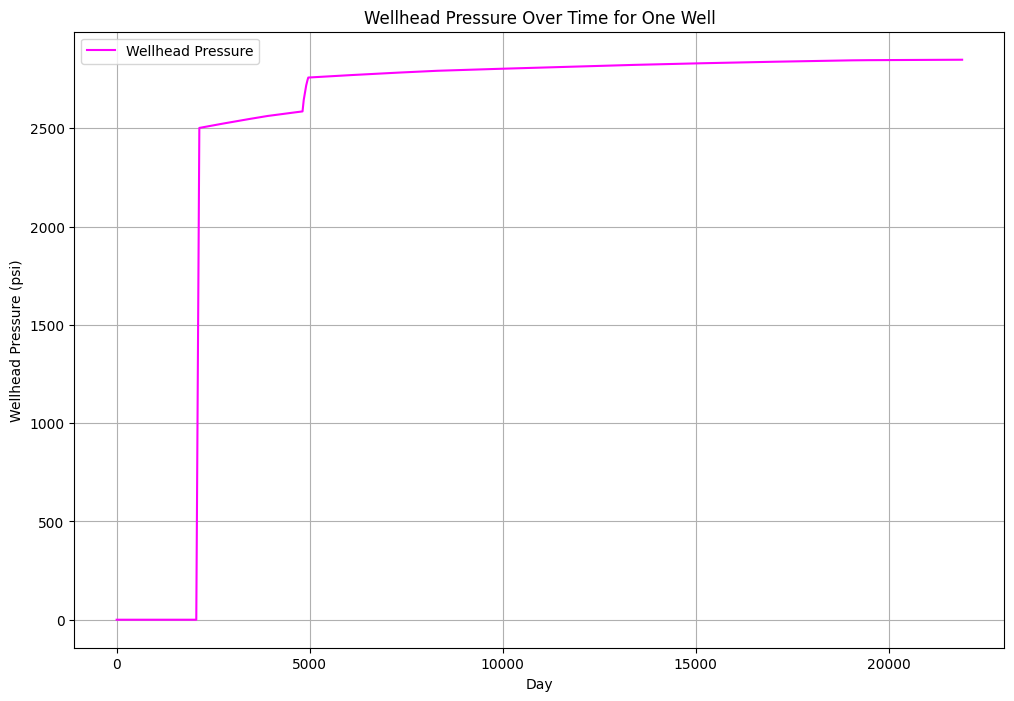

In [68]:
## Plot Wellhead Pressure over time
plt.figure(figsize=(12, 8))
sns.lineplot(x=production_df['Day'], y=production_df['Wellhead Pressure (psi)'], label='Wellhead Pressure', color='magenta')
plt.title('Wellhead Pressure Over Time for One Well')
plt.xlabel('Day')
plt.ylabel('Wellhead Pressure (psi)')
plt.legend()
plt.grid()

In [69]:
df_costs = production_df.copy()
df_costs['Water Treatment Cost ($/day)'] = df_costs['Water Production (STB/day)'] * water_treatment_cost_per_stb
df_costs['Gas Lift Cost ($/day)'] = df_costs['Gas Lift Injection Rate (mmscf/day)'] * (df_costs['Wellhead Pressure (psi)'] - separator_psi)* gli_cost_per_mmscf_psi
df_costs['Total Cost ($/day)'] = df_costs['Water Treatment Cost ($/day)'] + df_costs['Gas Lift Cost ($/day)']
df_costs['Total Cost ($/day)/Oil Production (STB/day)'] = df_costs['Total Cost ($/day)'] / df_costs['Oil Production (STB/day)']


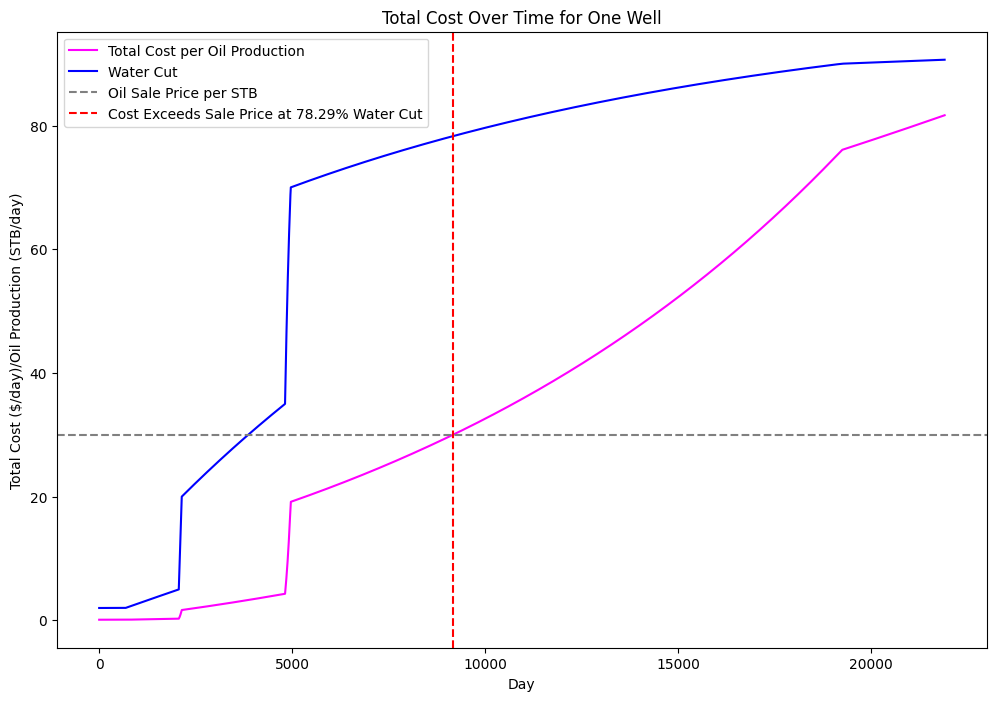

In [70]:
# PLotting Total Cost over time
plt.figure(figsize=(12, 8))
sns.lineplot(x=df_costs['Day'], y=df_costs['Total Cost ($/day)/Oil Production (STB/day)'], label='Total Cost per Oil Production', color='magenta')
# PLot water cut
sns.lineplot(x=df_costs['Day'], y=df_costs['Water Cut (%)'], label='Water Cut', color='blue')
## Draw a line with the oil sale price per stb as a reference
plt.axhline(y=oil_sale_price_per_stb, color='gray', linestyle='--', label='Oil Sale Price per STB')
## Find the water cut at which the total cost per oil production exceeds the oil sale price per stb
exceeding_cost = df_costs[df_costs['Total Cost ($/day)/Oil Production (STB/day)'] > oil_sale_price_per_stb]
if not exceeding_cost.empty:
    exceeding_water_cut = exceeding_cost['Water Cut (%)'].iloc[0]
    plt.axvline(x=exceeding_cost['Day'].iloc[0], color='red', linestyle='--', label=f'Cost Exceeds Sale Price at {exceeding_water_cut:.2f}% Water Cut')

plt.title('Total Cost Over Time for One Well')
plt.xlabel('Day')
plt.ylabel('Total Cost ($/day)/Oil Production (STB/day)')
plt.legend()

In [71]:
def calculate_wcut(gas_lift_cost, water_treatment_cost, oil_sale_price = oil_sale_price_per_stb):
    df_costs = production_df.copy()
    df_costs['Water Treatment Cost ($/day)'] = df_costs['Water Production (STB/day)'] * water_treatment_cost
    df_costs['Gas Lift Cost ($/day)'] = df_costs['Gas Lift Injection Rate (mmscf/day)'] * (df_costs['Wellhead Pressure (psi)'] - separator_psi)* gas_lift_cost
    df_costs['Total Cost ($/day)'] = df_costs['Water Treatment Cost ($/day)'] + df_costs['Gas Lift Cost ($/day)']
    df_costs['Total Cost ($/day)/Oil Production (STB/day)'] = df_costs['Total Cost ($/day)'] / df_costs['Oil Production (STB/day)']
    exceeding_cost = df_costs[df_costs['Total Cost ($/day)/Oil Production (STB/day)'] > oil_sale_price]
    if not exceeding_cost.empty:
        return exceeding_cost['Water Cut (%)'].iloc[0]
    else:
        return 95.0 # Return 95% if cost never exceeds sale price

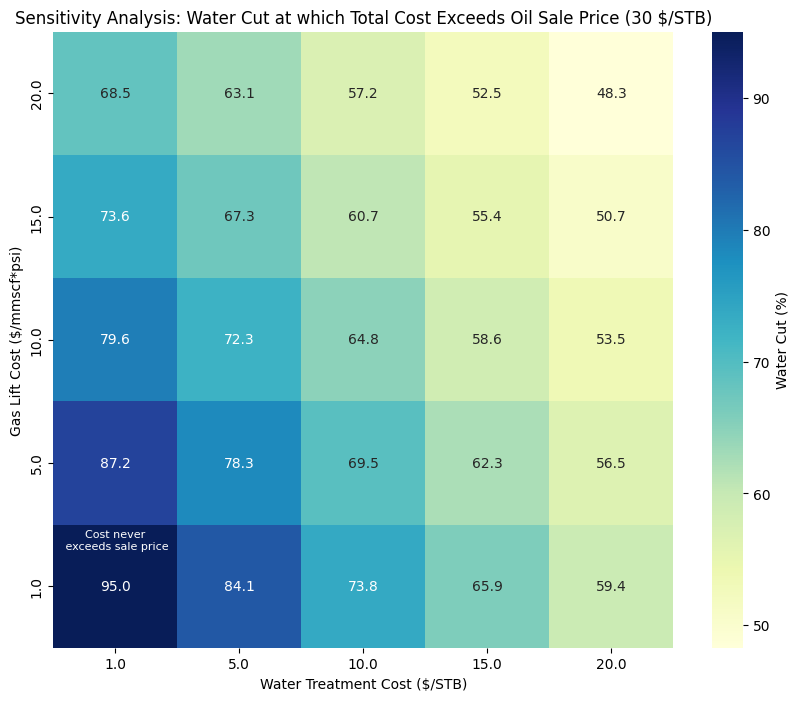

In [72]:
## Sensitivity analysis: Varying water treatment cost and gas lift cost
gas_lift_costs = [1.0, 5.0, 10.0, 15.0, 20]
water_treatment_costs = [1.0, 5.0, 10.0, 15.0, 20]

## Create a heatmap showing the wcut at which the total cost per oil production exceeds the oil sale price for each combination of water treatment cost and gas lift cost
sensitivity_results = []

for gas_lift_cost in gas_lift_costs:
    for water_treatment_cost in water_treatment_costs:
        # Calculate the wcut for the current combination of costs
        wcut = calculate_wcut(gas_lift_cost, water_treatment_cost)
        sensitivity_results.append((gas_lift_cost, water_treatment_cost, wcut))
sensitivity_df = pd.DataFrame(sensitivity_results, columns=['Gas Lift Cost ($/mmscf*psi)', 'Water Treatment Cost ($/STB)', 'Water Cut (%)'])
sensitivity_pivot = sensitivity_df.pivot(index='Gas Lift Cost ($/mmscf*psi)', columns='Water Treatment Cost ($/STB)', values='Water Cut (%)')
plt.figure(figsize=(10, 8))
## Plot heatmap with annotations inverting the y-axis to have the lowest gas lift cost at the top
sns.heatmap(sensitivity_pivot, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Water Cut (%)'})
plt.gca().invert_yaxis()
## If a cell value is 95.0, add a note that says "Cost never exceeds sale price"
for i in range(sensitivity_pivot.shape[0]):
    for j in range(sensitivity_pivot.shape[1]):
        if sensitivity_pivot.iloc[i, j] == 95.0:
            plt.text(j + 0.5, i + 0.5, 'Cost never\n exceeds sale price\n\n\n', ha='center', va='bottom', color='white', fontsize=8)


plt.title(f'Sensitivity Analysis: Water Cut at which Total Cost Exceeds Oil Sale Price ({oil_sale_price_per_stb} $/STB)')
plt.xlabel('Water Treatment Cost ($/STB)')
plt.ylabel('Gas Lift Cost ($/mmscf*psi)')
plt.show()


In [73]:
## Load gas lift wcut_gli table
gli_rate_table = pd.read_csv('datasets/part1.1_wcut_gli.csv', usecols=[0, 1, 2])
gli_rate_table.columns = ['Gas Lift Injection (GLI) Rate (mmscf/day)', 'Liquid Rate (STB/day)', 'Water Cut (%)']
## Load gas lift pressure table
gli_pressure_table = pd.read_csv('datasets/part1.1_pressure_gli.csv', usecols=[0, 1, 2])
gli_pressure_table.columns = ['Gas Lift Injection (GLI) Rate (mmscf/day)', 'Wellhead Pressure (psi)', 'Water Cut (%)']
gli_table = gli_rate_table.merge(gli_pressure_table, on=['Gas Lift Injection (GLI) Rate (mmscf/day)', 'Water Cut (%)'])
gli_table


,Gas Lift Injection (GLI) Rate (mmscf/day),Liquid Rate (STB/day),Water Cut (%),Wellhead Pressure (psi)
0,0.0,6570.797,2,0.000
1,0.2,6745.583,2,2442.798
2,0.4,6918.831,2,2461.667
3,0.6,7090.412,2,2480.887
4,0.8,7260.610,2,2500.377
...,...,...,...,...
72,1.2,5927.655,95,2882.106
73,1.4,6226.075,95,2872.069
74,1.6,6507.142,95,2865.735
75,1.8,6764.781,95,2864.410


In [74]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator

def build_gli_model(gli_table):
    """
    Builds interpolators for:
      - Liquid Rate (STB/day)
      - Wellhead Pressure (psi)

    from the dataframe gli_table.

    Required columns in gli_table:
      - 'Gas Lift Injection (GLI) Rate (mmscf/day)'
      - 'Water Cut (%)'
      - 'Liquid Rate (STB/day)'
      - 'Wellhead Pressure (psi)'

    Returns
    -------
    model : function
        Function that receives:
            water_cut, gli_rate
        and returns:
            liquid_rate, wellhead_pressure
    """

    points = gli_table[[
        'Gas Lift Injection (GLI) Rate (mmscf/day)',
        'Water Cut (%)'
    ]].values

    liquid_values = gli_table['Liquid Rate (STB/day)'].values
    pressure_values = gli_table['Wellhead Pressure (psi)'].values

    liquid_interp = LinearNDInterpolator(points, liquid_values)
    pressure_interp = LinearNDInterpolator(points, pressure_values)

    def model(water_cut, gli_rate):
        
        liquid_rate = liquid_interp(gli_rate, water_cut)
        wellhead_pressure = pressure_interp(gli_rate, water_cut)

        if np.isnan(liquid_rate) or np.isnan(wellhead_pressure):
            # raise ValueError(
            #     "Input (water_cut, gli_rate) is outside the interpolation range."
            # )
            return max_rate_per_well, 0

        return float(liquid_rate), float(wellhead_pressure)

    return model

gli_model = build_gli_model(gli_table)

In [75]:
gli_model(40, 0.0)

(5820.212285714287, 0.0)

In [76]:
## Optimize the gas lift injection rate to minimize the total cost per oil production

min_gli_rate = 0.0
max_gli_rate = 2.0
cumulative_production = 0
daily_oil_production = []
daily_water_production = []
daily_gas_production = []
daily_water_cut = []
daily_gas_lift_rate = []
daily_liquid_rate = []
daily_profitability = []
for days in range(total_days):
    # find wcut for the current day
    current_wcut = np.interp(cumulative_production, df_wcut_vs_np['NP per well [MSTB,oil]'], df_wcut_vs_np['WC [%]'])
    ## Find maximum liquid rate with highest profitability (oil sale price - total cost per oil production)
    def find_best_gli_rate(current_wcut=current_wcut):
        gli_rate = 0
        liquid_rate, wellhead_pressure = gli_model(current_wcut, gli_rate)
        if liquid_rate > max_rate_per_well:
            liquid_rate = max_rate_per_well
        oil_rate = liquid_rate * (1 - current_wcut / 100)
        water_production = liquid_rate * (current_wcut / 100)
        gas_production = oil_rate * GOR / 1000  # Convert to M
        water_treatment_cost = water_production * water_treatment_cost_per_stb
        gas_lift_cost = 0
        total_cost = water_treatment_cost + gas_lift_cost
        profit = oil_rate*oil_sale_price_per_stb - total_cost
        best_gli_rate = 0
        for gli_rate in np.linspace(min_gli_rate, max_gli_rate, 21):
            liquid_rate, wellhead_pressure = gli_model(current_wcut, gli_rate)
            # print(liquid_rate, wellhead_pressure)
            if liquid_rate > max_rate_per_well:
                liquid_rate = max_rate_per_well
            oil_rate = liquid_rate * (1 - current_wcut / 100)
            water_production = liquid_rate * (current_wcut / 100)
            gas_production = oil_rate * GOR / 1000  # Convert to Mscf
            water_treatment_cost = water_production * water_treatment_cost_per_stb
            gas_lift_cost = gli_rate * (wellhead_pressure - separator_psi) * gli_cost_per_mmscf_psi
            total_cost = water_treatment_cost + gas_lift_cost
            current_profit = oil_rate*oil_sale_price_per_stb - total_cost
            if current_profit > profit:
                # print(best_gli_rate, current_profit)
                profit = current_profit
                best_gli_rate = gli_rate
        return best_gli_rate, profit
    
    optimized_gli_rate, _ = find_best_gli_rate()
    liquid_rate, wellhead_pressure = gli_model(current_wcut, optimized_gli_rate)
    if liquid_rate > max_rate_per_well:
        liquid_rate = max_rate_per_well
    oil_rate = liquid_rate * (1 - current_wcut / 100)
    water_production = liquid_rate * (current_wcut / 100)
    gas_production = oil_rate * GOR / 1000  # Convert to Mscf
    
    
    daily_oil_production.append(oil_rate)
    daily_water_production.append(water_production)
    daily_gas_production.append(gas_production)
    daily_water_cut.append(current_wcut)
    daily_gas_lift_rate.append(optimized_gli_rate)
    daily_liquid_rate.append(liquid_rate)
    water_treatment_cost = water_production * water_treatment_cost_per_stb
    gas_lift_cost = optimized_gli_rate * (wellhead_pressure - separator_psi) * gli_cost_per_mmscf_psi
    daily_profitability.append(oil_sale_price_per_stb - (water_treatment_cost + gas_lift_cost) / oil_rate if oil_rate > 0 else -np.inf)

    cumulative_production += oil_rate/1000  # Convert to MSTB
    # Print current day without create new line
    print(f'Day {days+1}/{total_days} Water Rate: {water_production:.2f} STB/day  Gas Lift Rate: {optimized_gli_rate:.2f} mmscf/day', end='\r')

        
df_optimized = pd.DataFrame({
    'Day': range(1, total_days + 1),
    'Oil Production (STB/day)': daily_oil_production,
    'Water Production (STB/day)': daily_water_production,
    'Gas Production (Mscf/day)': daily_gas_production,
    'Water Cut (%)': daily_water_cut,
    'Gas Lift Injection Rate (mmscf/day)': daily_gas_lift_rate,
    'Liquid Rate (STB/day)': daily_liquid_rate
})

In [77]:
# ## Optimize the gas lift injection rate to minimize the total cost per oil production
# from scipy.optimize import minimize

# min_gli_rate = 0.2
# max_gli_rate = 2
# cumulative_production = 0
# daily_oil_production = []
# daily_water_production = []
# daily_gas_production = []
# daily_water_cut = []
# daily_gas_lift_rate = []
# daily_liquid_rate = []
# daily_profitability = []
# for days in range(total_days):
#     # find wcut for the current day
#     current_wcut = np.interp(cumulative_production, df_wcut_vs_np['NP per well [MSTB,oil]'], df_wcut_vs_np['WC [%]'])
#     ## Find maximum liquid rate with highest profitability (oil sale price - total cost per oil production)
#     def objective(gli_rate, current_wcut=current_wcut):
#         liquid_rate, wellhead_pressure = gli_model(current_wcut, gli_rate)
#         if liquid_rate > max_rate_per_well:
#             return -np.inf  # Penalize solutions that exceed maximum rate per well
#         water_production = liquid_rate * (current_wcut / 100)
#         oil_production = liquid_rate * (1 - current_wcut / 100)
#         gas_production = oil_production * GOR / 1000  # Convert to Mscf

#         water_treatment_cost = water_production * water_treatment_cost_per_stb
#         gas_lift_cost = gli_rate * (wellhead_pressure - separator_psi) * gli_cost_per_mmscf_psi
#         total_cost = water_treatment_cost + gas_lift_cost
#         cost_per_oil = total_cost / oil_production if oil_production > 0 else np.inf

#         # We want to minimize the cost per oil production, but also consider the sale price
#         profitability = oil_sale_price_per_stb - cost_per_oil
#         return -profitability  # Negate because we want to maximize profitability
    
#     initial_gli_rate = production_df.loc[days, 'Gas Lift Injection Rate (mmscf/day)']
#     if initial_gli_rate != 0:
#         result = minimize(objective, x0=initial_gli_rate, bounds=[(min_gli_rate, max_gli_rate)])
#         optimized_gli_rate = result.x[0]
#         liquid_rate, wellhead_pressure = gli_model(current_wcut, optimized_gli_rate)
#         oil_rate = liquid_rate * (1 - current_wcut / 100)
#         water_production = liquid_rate * (current_wcut / 100)
#         gas_production = oil_rate * GOR / 1000  # Convert to Mscf
#         # print(result.fun)
#     else:
#         liquid_rate = max_rate_per_well
#         oil_rate = liquid_rate * (1 - current_wcut / 100)
#         water_production = liquid_rate * (current_wcut / 100)
#         gas_production = oil_rate * GOR / 1000  # Convert to Mscf
#         gas_lift_cost = 0
#         optimized_gli_rate = 0
    
#     daily_oil_production.append(oil_rate)
#     daily_water_production.append(water_production)
#     daily_gas_production.append(gas_production)
#     daily_water_cut.append(current_wcut)
#     daily_gas_lift_rate.append(optimized_gli_rate)
#     daily_liquid_rate.append(liquid_rate)
#     water_treatment_cost = water_production * water_treatment_cost_per_stb
#     daily_profitability.append(oil_sale_price_per_stb - (water_treatment_cost + gas_lift_cost) / oil_rate if oil_rate > 0 else -np.inf)

#     cumulative_production += oil_rate/1000  # Convert to MSTB
#     # Print current day without create new line
#     print(f'Day {days+1}/{total_days} Water Rate: {water_production:.2f} STB/day    ', end='\r')

        
# df_optimized = pd.DataFrame({
#     'Day': range(1, total_days + 1),
#     'Oil Production (STB/day)': daily_oil_production,
#     'Water Production (STB/day)': daily_water_production,
#     'Gas Production (Mscf/day)': daily_gas_production,
#     'Water Cut (%)': daily_water_cut,
#     'Gas Lift Injection Rate (mmscf/day)': daily_gas_lift_rate,
#     'Liquid Rate (STB/day)': daily_liquid_rate
# })
    

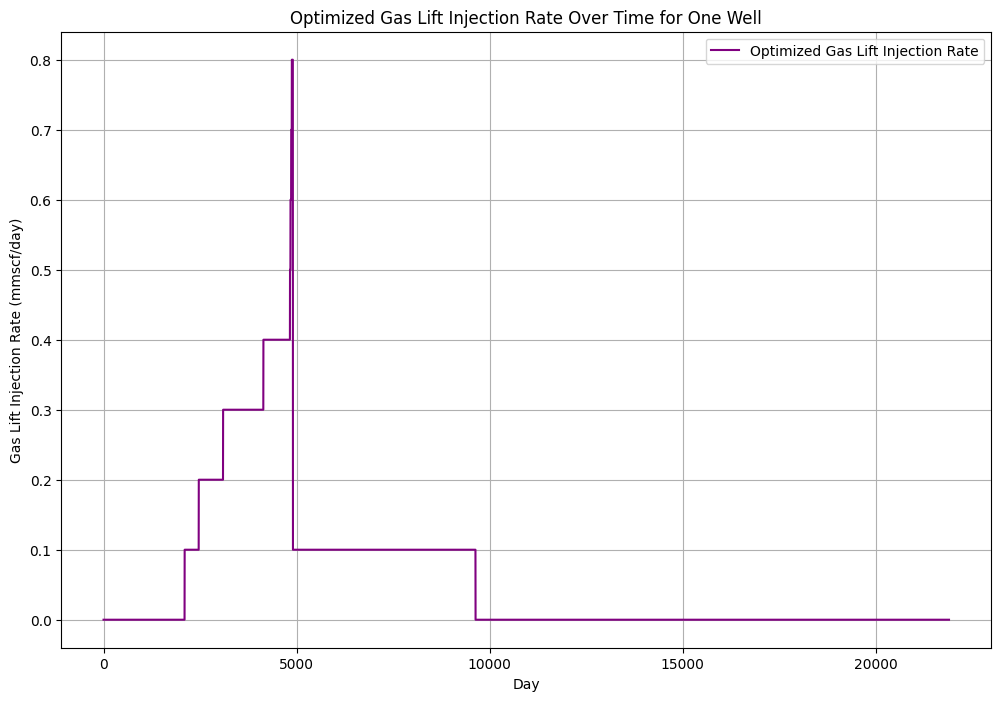

In [78]:
# PLot optimized gas lift injection rate over time
plt.figure(figsize=(12, 8))
sns.lineplot(x=df_optimized['Day'], y=df_optimized['Gas Lift Injection Rate (mmscf/day)'], label='Optimized Gas Lift Injection Rate', color='purple')
plt.title('Optimized Gas Lift Injection Rate Over Time for One Well')
plt.xlabel('Day')
plt.ylabel('Gas Lift Injection Rate (mmscf/day)')
plt.legend()
plt.grid()

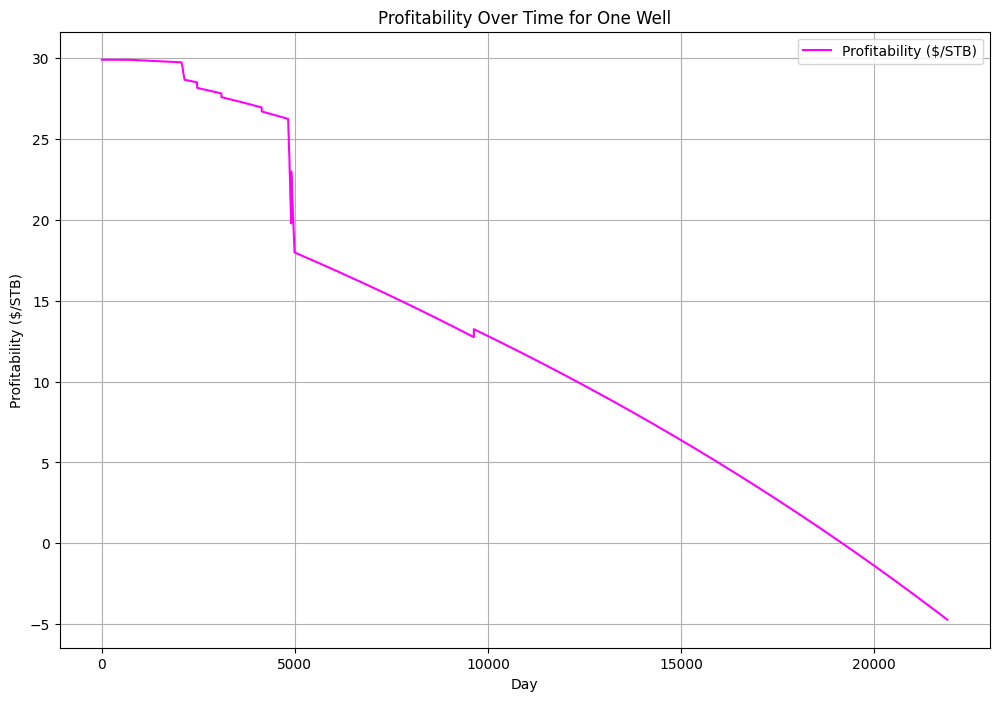

In [79]:
# PLot profitability over time
plt.figure(figsize=(12, 8))
sns.lineplot(x=df_optimized['Day'], y=daily_profitability, label='Profitability ($/STB)', color='magenta')
plt.title('Profitability Over Time for One Well')
plt.xlabel('Day')
plt.ylabel('Profitability ($/STB)')
plt.legend()
plt.grid()

In [80]:
# Show difference of days to reach profitability of 0 between optimized and non-optimized gas lift injection rate
non_optimized_profitability = production_df.apply(lambda row: oil_sale_price_per_stb - ((row['Water Production (STB/day)'] * water_treatment_cost_per_stb + row['Gas Lift Injection Rate (mmscf/day)'] * (row['Wellhead Pressure (psi)'] - separator_psi) * gli_cost_per_mmscf_psi) / row['Oil Production (STB/day)']) if row['Oil Production (STB/day)'] > 0 else -np.inf, axis=1)
non_optimized_profitability = non_optimized_profitability.replace(-np.inf, np.nan)
optimized_profitability = pd.Series(daily_profitability).replace(-np.inf, np.nan)
non_optimized_zero_profit_day = non_optimized_profitability[non_optimized_profitability <= 0].index.min()
optimized_zero_profit_day = optimized_profitability[optimized_profitability <= 0].index.min()
print(f'Day to reach 0 profitability with non-optimized GLI: {non_optimized_zero_profit_day}')
print(f'Day to reach 0 profitability with optimized GLI: {optimized_zero_profit_day}')

Day to reach 0 profitability with non-optimized GLI: 9163
Day to reach 0 profitability with optimized GLI: 19178


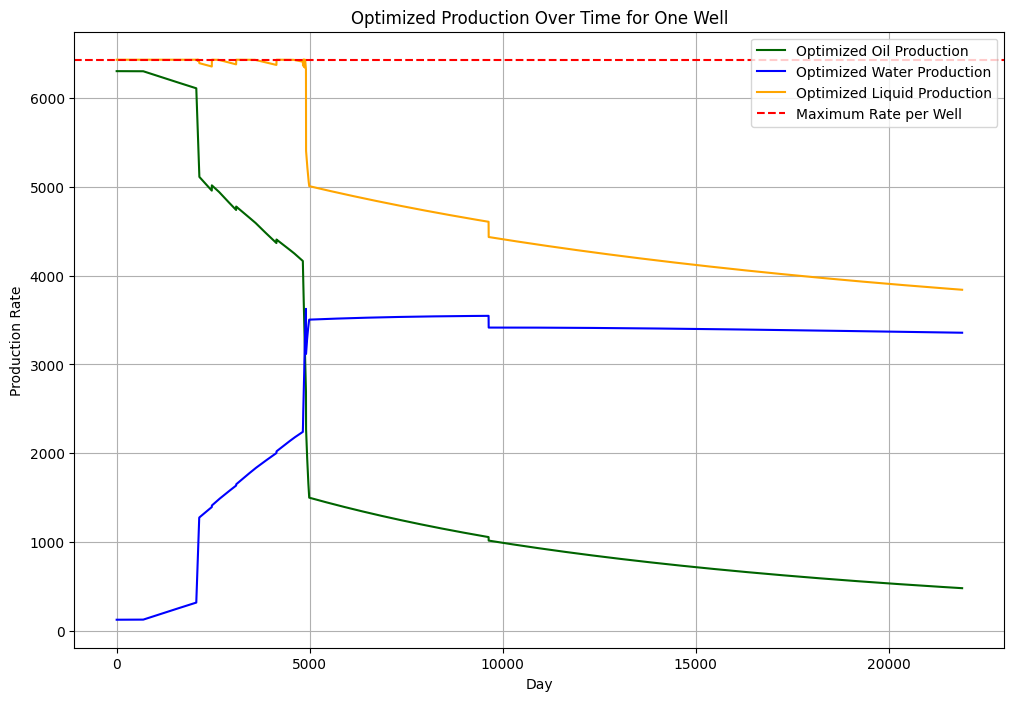

In [81]:
# Plot optimized liquid rate over time
plt.figure(figsize=(12, 8))
sns.lineplot(x=df_optimized['Day'], y=df_optimized['Oil Production (STB/day)'], label='Optimized Oil Production', color='darkgreen')
sns.lineplot(x=df_optimized['Day'], y=df_optimized['Water Production (STB/day)'], label='Optimized Water Production', color='blue')
sns.lineplot(x=df_optimized['Day'], y=df_optimized['Liquid Rate (STB/day)'], label='Optimized Liquid Production', color='orange')
# Show a line with the maximum rate per well as reference
plt.axhline(y=max_rate_per_well, color='red', linestyle='--', label='Maximum Rate per Well')
plt.title('Optimized Production Over Time for One Well')
plt.xlabel('Day')
plt.ylabel('Production Rate')
plt.legend()
plt.grid()

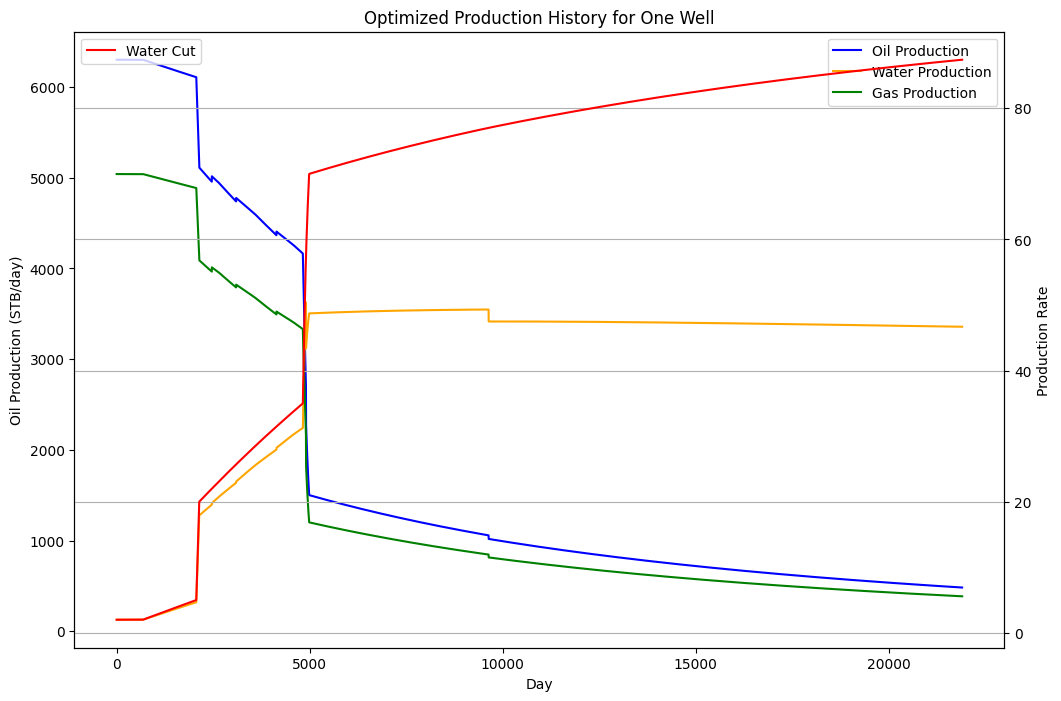

In [82]:
# Plot optimized production history
plt.figure(figsize=(12, 8))
sns.lineplot(x=df_optimized['Day'], y=df_optimized['Oil Production (STB/day)'], label='Oil Production', color='blue')
sns.lineplot(x=df_optimized['Day'], y=df_optimized['Water Production (STB/day)'], label='Water Production', color='orange')
sns.lineplot(x=df_optimized['Day'], y=df_optimized['Gas Production (Mscf/day)'], label='Gas Production', color='green')
## Plot water cut on secondary y-axis
ax2 = plt.gca().twinx()
sns.lineplot(x=df_optimized['Day'], y=df_optimized['Water Cut (%)'], label='Water Cut', color='red', ax=ax2)
ax2.set_ylabel('Water Cut (%)')
plt.title('Optimized Production History for One Well')
plt.xlabel('Day')
plt.ylabel('Production Rate')
plt.legend()
plt.grid()


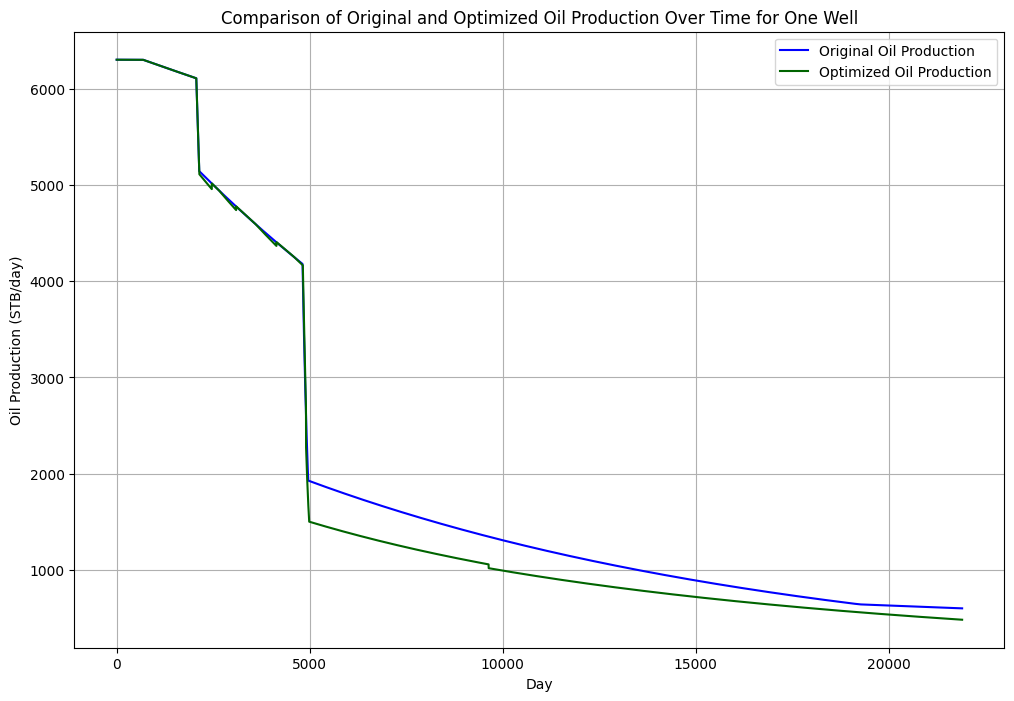

In [83]:
# Compare optimized oil production with original production
plt.figure(figsize=(12, 8)) 
sns.lineplot(x=production_df['Day'], y=production_df['Oil Production (STB/day)'], label='Original Oil Production', color='blue')
sns.lineplot(x=df_optimized['Day'], y=df_optimized['Oil Production (STB/day)'], label='Optimized Oil Production', color='darkgreen')
plt.title('Comparison of Original and Optimized Oil Production Over Time for One Well')
plt.xlabel('Day')
plt.ylabel('Oil Production (STB/day)')
plt.legend()
plt.grid()

In [84]:
# Open network excel output file
# Combine all sheets into a single DataFrame
file_path = "datasets/part1.3_well_results.xlsx"
## get all sheets into a dictionary
sheets_dict = pd.read_excel(file_path, sheet_name=None)
df_wells_results = pd.concat(
    [df.assign(Sheet=name) for name, df in sheets_dict.items()],
    ignore_index=True
)
# Separate collumn 'sheet' by '-'
df_wells_results[['Number of Wells', 'WC']] = df_wells_results['Sheet'].str.split('-', expand=True)
df_wells_results.head()




,Name,Type,Branch,Pressure (out),Temperature (out),ST Liquid Rate,ST Oil Rate,ST Water Rate,ST Gas Rate,ST GOR,ST Wcut,Fl Gas Rate,Fl Wcut,Sheet,Number of Wells,WC
0,Cpl,Completion,W1,2510.563,200.4512,6460.354,6137.337,323.0177,4.909869,800.0,5.0,0.013072,4.043688,7-5%,7,5%
1,Cpl,Completion,W3,2507.191,200.4527,6474.239,6150.527,323.7120,4.920422,800.0,5.0,0.013148,4.044794,7-5%,7,5%
2,Cpl,Completion,W7,2534.575,200.4407,6361.018,6042.968,318.0509,4.834374,800.0,5.0,0.012541,4.035801,7-5%,7,5%
3,Cpl,Completion,W5,2536.689,200.4398,6352.231,6034.620,317.6116,4.827696,800.0,5.0,0.012495,4.035106,7-5%,7,5%
4,Cpl,Completion,W4,2492.214,200.4591,6535.727,6208.941,326.7864,4.967153,800.0,5.0,0.013488,4.049705,7-5%,7,5%


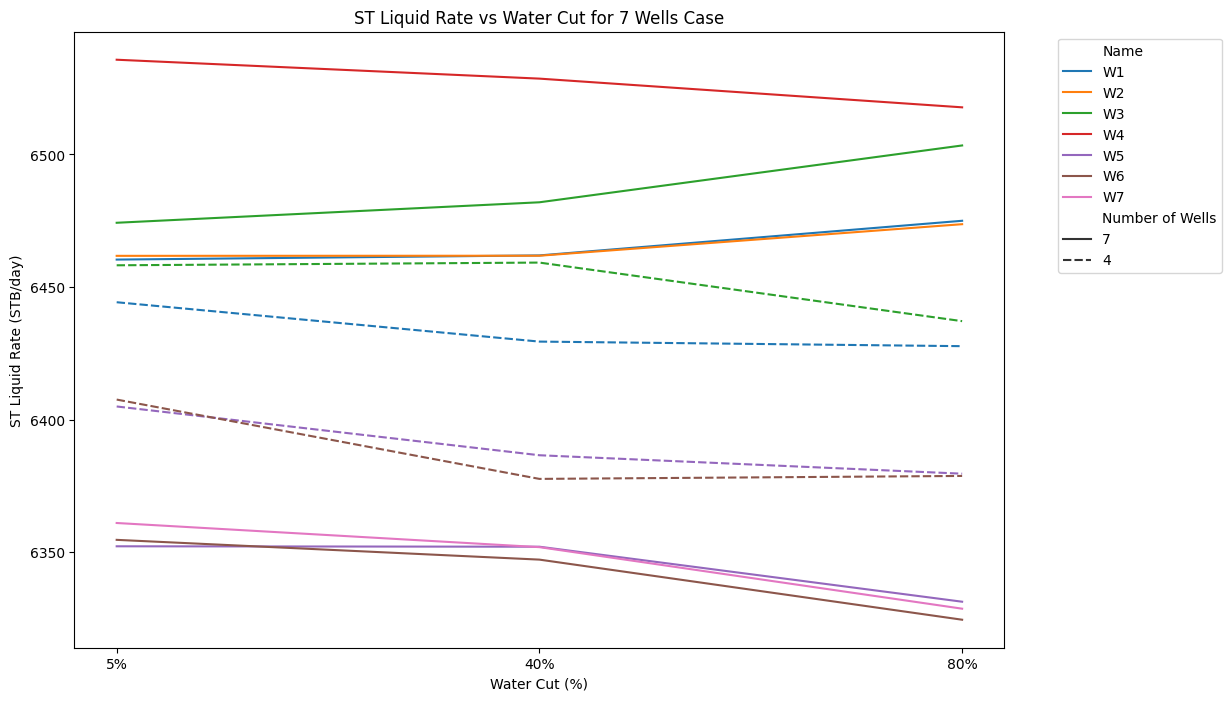

In [85]:
## Show the 'ST Liquid Rate' vc WC for 7 and 4 wells cases

names_to_filter = ['W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7']
filtered_df = df_wells_results[df_wells_results['Name'].isin(names_to_filter)]
plt.figure(figsize=(12, 8))
sns.lineplot(data=filtered_df, x='WC', y='ST Liquid Rate', hue='Name', style='Number of Wells')
plt.title('ST Liquid Rate vs Water Cut for 7 Wells Case')
plt.xlabel('Water Cut (%)')
plt.ylabel('ST Liquid Rate (STB/day)')
## Position the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


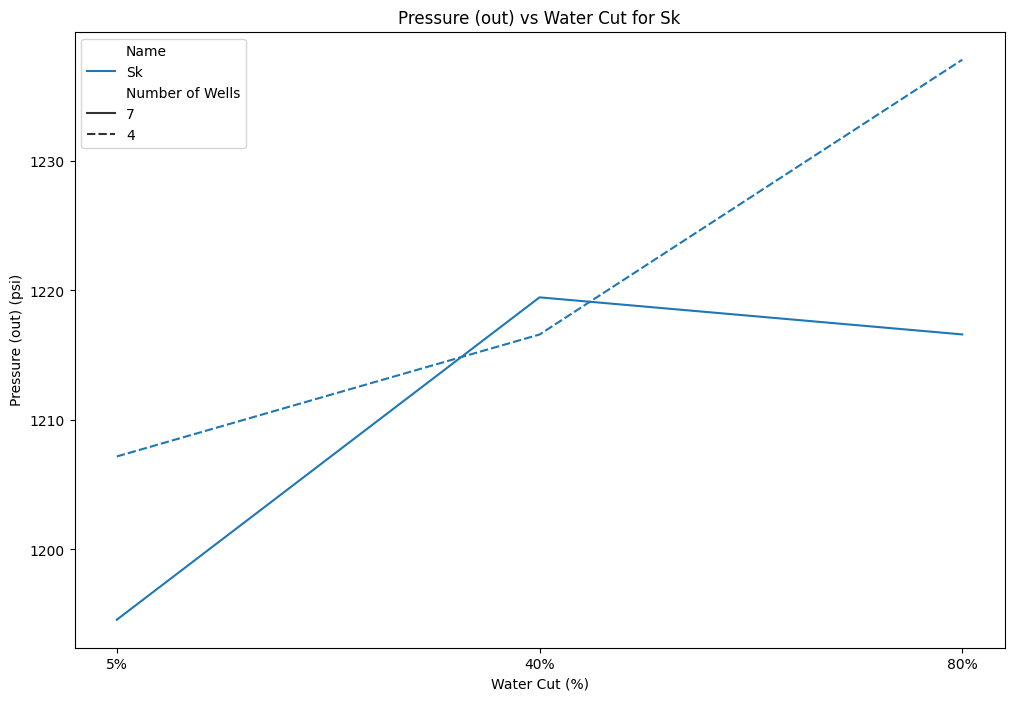

In [86]:
## Plot 'Pressure (out)' vs 'WC' for 7 and 4 wells cases for the 'Sk'
names_to_filter = ['Sk']
filtered_df = df_wells_results[df_wells_results['Name'].isin(names_to_filter)]
plt.figure(figsize=(12, 8))
sns.lineplot(data=filtered_df, x='WC', y='Pressure (out)', hue='Name', style='Number of Wells')
plt.title('Pressure (out) vs Water Cut for Sk')
plt.xlabel('Water Cut (%)')
plt.ylabel('Pressure (out) (psi)')
plt.legend()


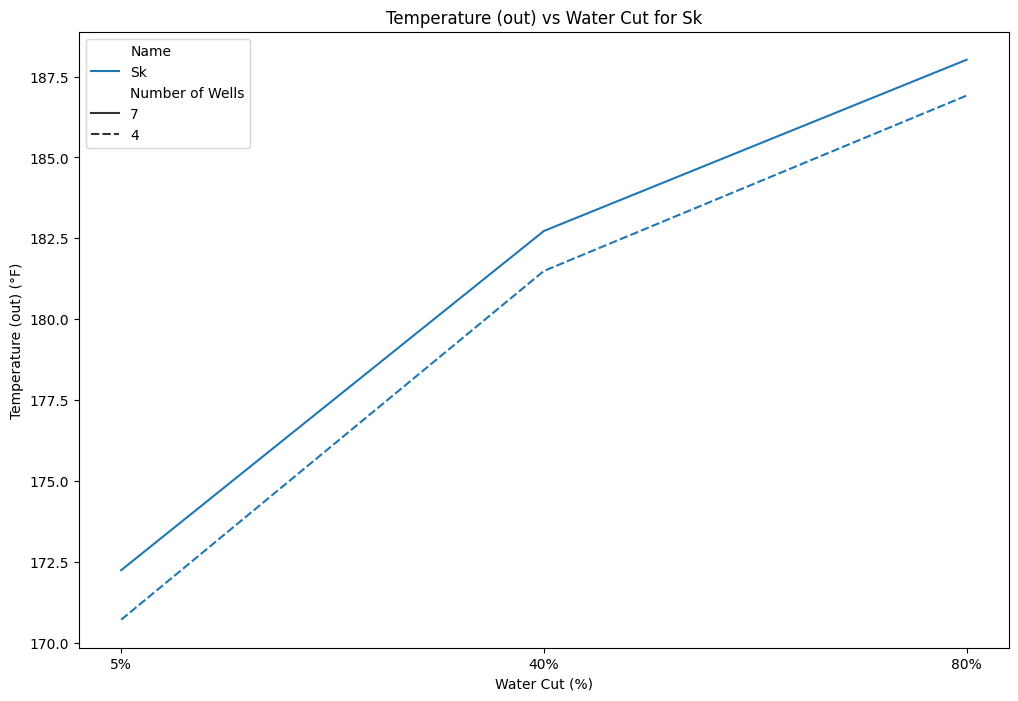

In [87]:
## Plot 'Pressure (out)' vs 'WC' for 7 and 4 wells cases for the 'Sk'
names_to_filter = ['Sk']
filtered_df = df_wells_results[df_wells_results['Name'].isin(names_to_filter)]
plt.figure(figsize=(12, 8))
sns.lineplot(data=filtered_df, x='WC', y='Temperature (out)', hue='Name', style='Number of Wells')
plt.title('Temperature (out) vs Water Cut for Sk')
plt.xlabel('Water Cut (%)')
plt.ylabel('Temperature (out) (°F)')
plt.legend()